Analysis Exploratorio, EDA

In [13]:
#Importamos las Libererias
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#Ponemos Base de Datos Limpiua
df= pd.read_csv("C:/Users/salaz/OneDrive/Desktop/Ciencia de Datos/Proyecto NFL/Data/Base de Datos Limpia")
df

,Year,Name,College,POS,Height (in),Weight (lbs),Hand Size (in),Arm Length (in),Wonderlic,40 Yard,Bench Press,Vert Leap (in),Broad Jump (in),Shuttle,3Cone,60Yd Shuttle
0,1987.0,Mike Adams,Arizona State,CB,74.00,198.0,8.50,30.50,24.0,4.42,13.0,32.0,118.0,4.60,9.99,11.65
1,1987.0,John Adickes,Florida State,C,74.00,266.0,10.25,30.00,24.0,4.80,25.0,26.5,103.0,4.60,9.99,11.65
2,1987.0,Tommy Agee,Auburn,FB,74.00,217.0,9.00,30.75,24.0,9.99,15.0,32.0,113.0,9.99,9.99,11.65
3,1987.0,David Alexander,Florida State,C,75.00,279.0,10.50,32.25,24.0,5.13,22.0,27.5,113.0,4.33,9.99,11.65
4,1987.0,Lyneal Alston,Southern Mississippi,WR,72.10,202.0,10.00,33.00,24.0,4.64,7.0,32.0,114.0,4.52,9.99,11.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10427,2015.0,Steve Smith,Michigan State,FS,72.63,208.0,10.38,32.25,24.0,4.65,20.0,32.0,119.0,4.33,7.09,11.65
10428,2001.0,Steve Smith,Penn State,CB,72.30,199.0,8.50,31.00,24.0,4.53,20.0,34.5,113.0,4.27,7.21,11.84
10429,2014.0,James Morris,Iowa,ILB,72.88,241.0,9.13,30.75,24.0,4.80,18.0,34.5,116.0,4.36,6.94,11.65
10430,1991.0,Todd Scott,Southwestern Louisiana,CB,70.40,204.0,9.63,31.00,24.0,4.65,14.0,33.0,113.0,4.52,9.99,11.41


In [14]:
df.describe()

,Year,Height (in),Weight (lbs),Hand Size (in),Arm Length (in),Wonderlic,40 Yard,Bench Press,Vert Leap (in),Broad Jump (in),Shuttle,3Cone,60Yd Shuttle
count,10432.00000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000,10432.000000
mean,2002.17015,73.751445,239.901361,9.524298,32.231532,24.005176,5.264316,19.903566,32.008388,112.541986,5.878212,8.823310,11.657471
std,9.04947,2.574525,44.286445,0.569471,1.331354,1.538492,1.461958,5.310013,3.686611,8.057599,2.466799,1.346569,0.229883
min,1987.00000,64.900000,142.000000,7.130000,25.630000,4.000000,4.210000,1.000000,17.500000,7.000000,3.730000,6.340000,10.430000
25%,1994.00000,72.000000,204.000000,9.250000,31.500000,24.000000,4.610000,18.000000,30.000000,109.000000,4.280000,7.340000,11.650000
50%,2002.00000,74.000000,232.000000,9.500000,32.250000,24.000000,4.800000,20.000000,32.000000,113.000000,4.520000,9.990000,11.650000
75%,2010.00000,75.600000,273.000000,9.880000,33.000000,24.000000,5.140000,22.000000,34.000000,117.000000,9.990000,9.990000,11.650000
max,2017.00000,82.400000,387.000000,11.880000,38.500000,48.000000,9.990000,51.000000,46.000000,147.000000,9.990000,9.990000,13.910000


In [15]:
df.columns

Index(['Year', 'Name', 'College', 'POS', 'Height (in)', 'Weight (lbs)',
       'Hand Size (in)', 'Arm Length (in)', 'Wonderlic', '40 Yard',
       'Bench Press', 'Vert Leap (in)', 'Broad Jump (in)', 'Shuttle', '3Cone',
       '60Yd Shuttle'],
      dtype='object')

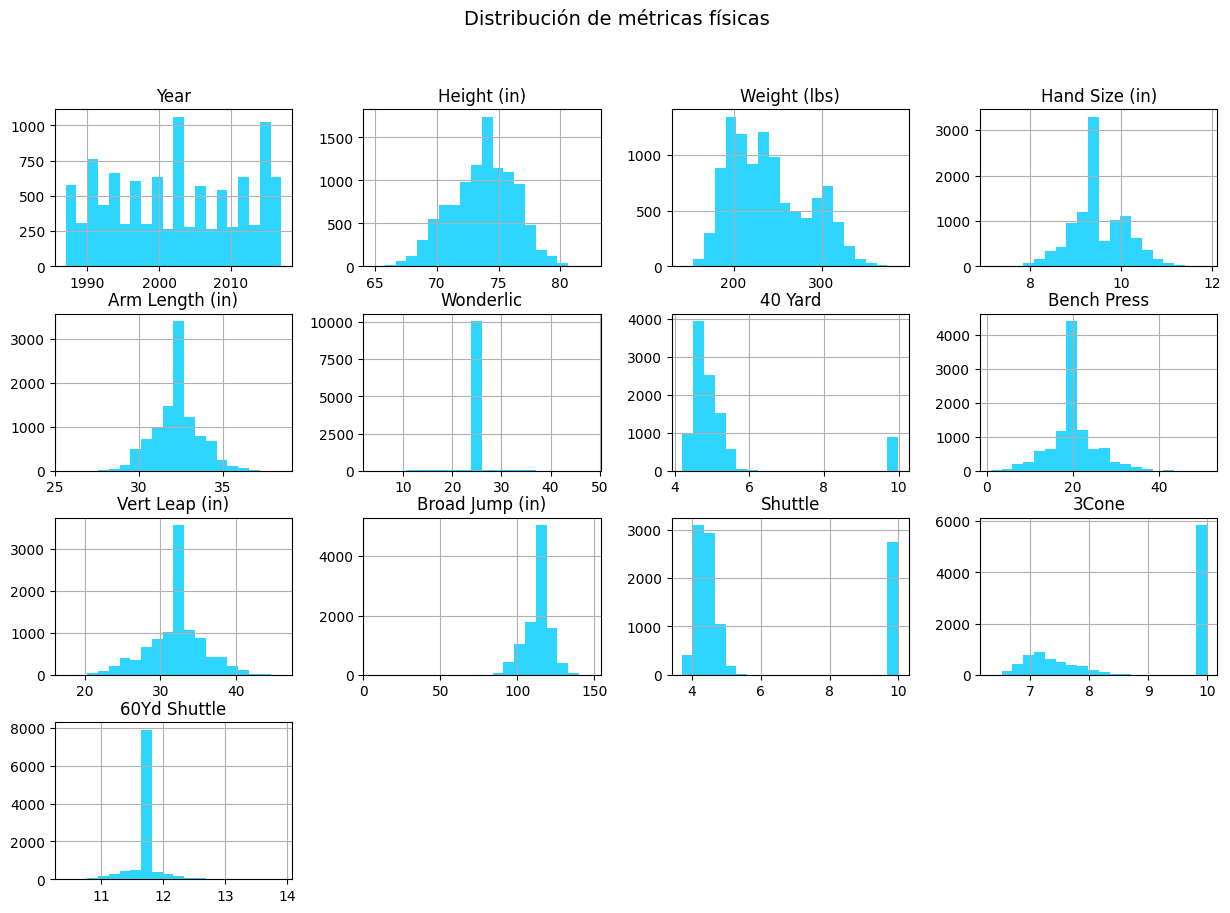

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(bins=20, figsize=(15,10), color="#00CCFFD2")
plt.suptitle("Distribución de métricas físicas", fontsize=14)
plt.show()

POS
WR     1671
CB     1003
RB      935
OT      798
OLB     798
DE      783
DT      736
OG      603
QB      592
TE      586
FS      404
ILB     402
SS      363
C       310
FB      255
P        69
K        61
LB       20
G        19
LS        9
DL        5
DB        5
OL        4
NT        1
Name: count, dtype: int64


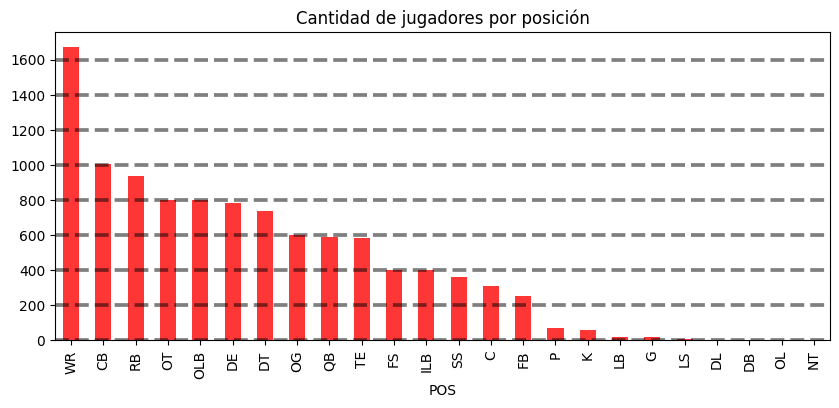

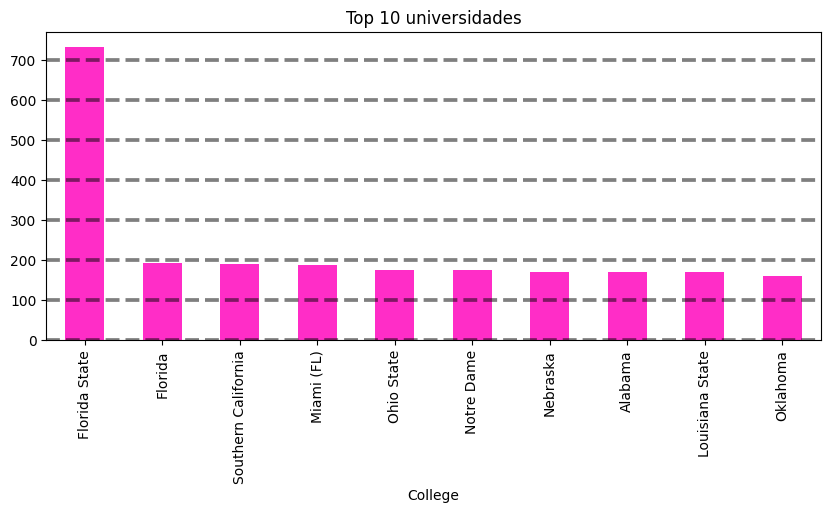

In [17]:
#Cuantos jugadores hay x pocision
print(df['POS'].value_counts())

#Grafuca de cuantos jugadores hay por pocision 
df['POS'].value_counts().plot(kind='bar', figsize=(10,4), title="Cantidad de jugadores por posición", color="#FF0C0CD3")
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=2.7, alpha=0.5,color="black")
plt.show()

#Top 10 de universidades que llegan más al DRAFT 
df['College'].value_counts().head(10).plot(kind='bar', figsize=(10,4), title="Top 10 universidades", color="#FF00BBD2")
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=2.7, alpha=0.5,color="black")
plt.show()

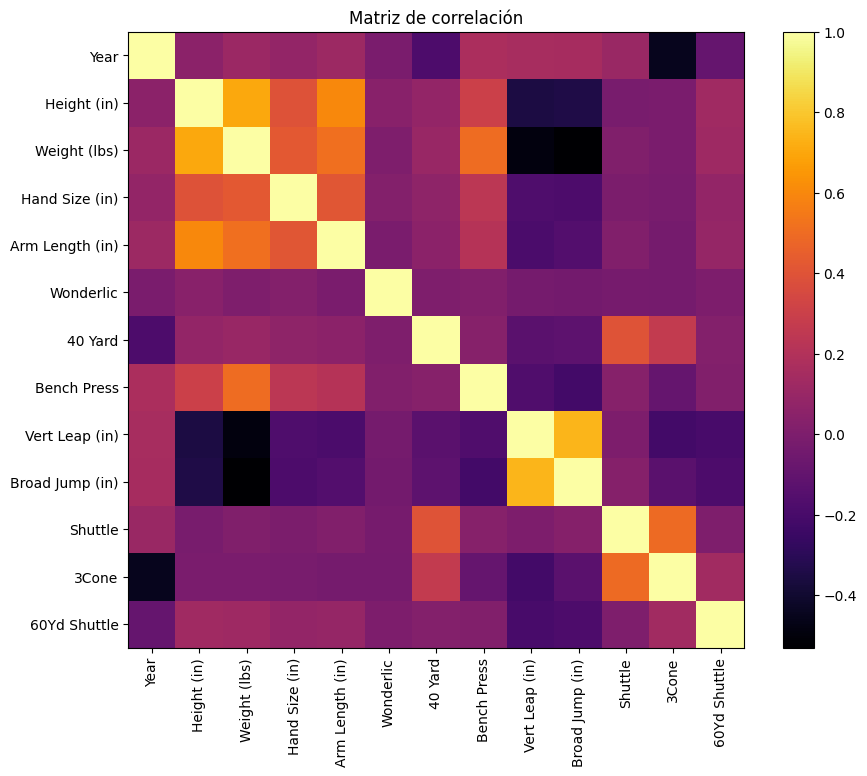

In [18]:
#Matriz de Correlación

correlacion = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(correlacion, cmap='inferno', interpolation='nearest')
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.colorbar()
plt.title("Matriz de correlación")
plt.show()

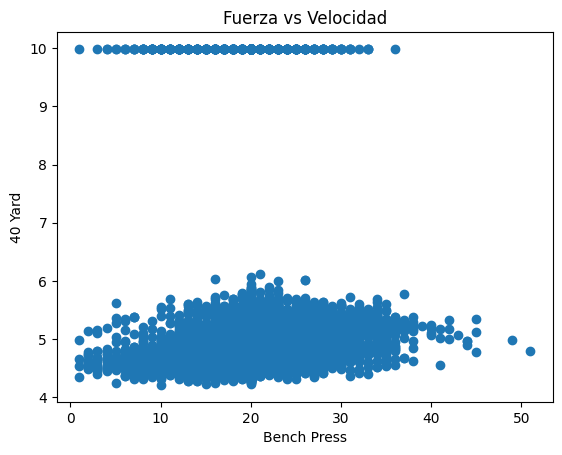

In [19]:
#Comparacion entre Velocidad y Fuerza

plt.scatter(df["Bench Press"], df["40 Yard"])
plt.xlabel("Bench Press")
plt.ylabel("40 Yard")
plt.title("Fuerza vs Velocidad")
plt.show()

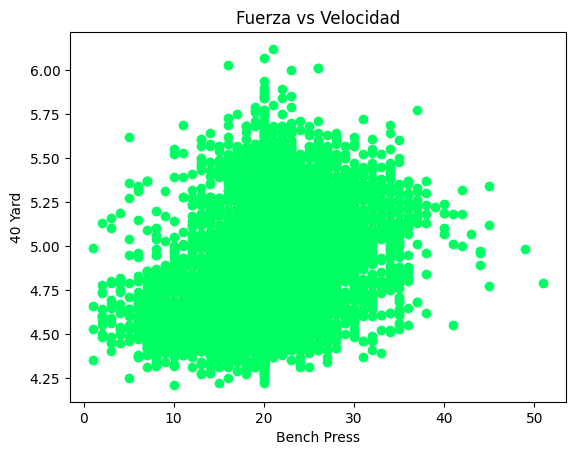

In [20]:
#Aqui tenemos en la prueba de 40 yardas me di cuenta que hay varios jugadores que tienen tiempos muy altos, 
# lo cual no es posible en la realidad, por lo que decidí eliminar esos valores atípicos para tener un análisis más preciso.
# igualmente el mejor tiempo en las 40 yardas es de 4.22 segundos, por lo que establecí un rango entre 4.0 y 7.0 segundos.
df = df[(df["40 Yard"] < 7.0) & (df["40 Yard"] > 4.0)]
plt.scatter(df["Bench Press"], df["40 Yard"], color="#00FF62FF")
plt.xlabel("Bench Press")
plt.ylabel("40 Yard")
plt.title("Fuerza vs Velocidad")

plt.show()


<Figure size 1200x600 with 0 Axes>

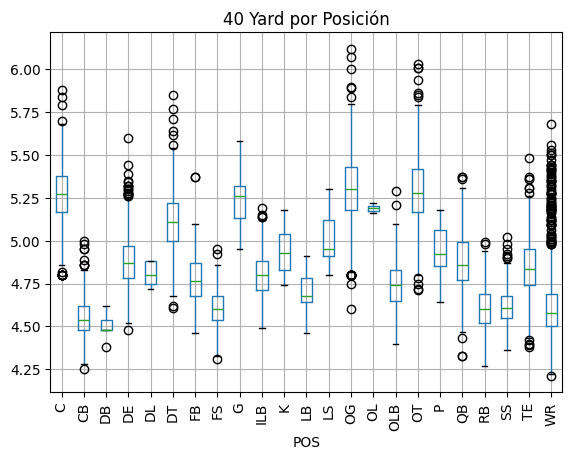

<Figure size 1200x600 with 0 Axes>

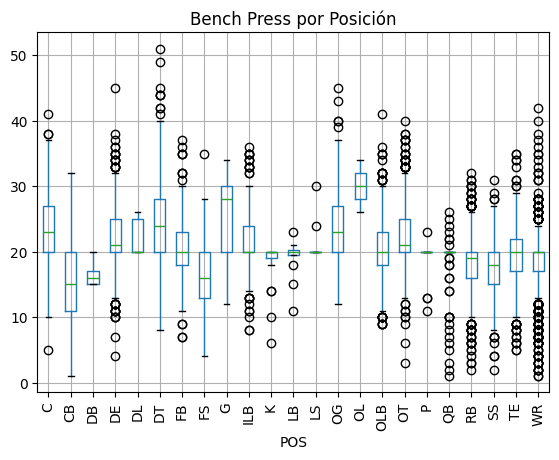

In [21]:
positions = df['POS'].unique()

plt.figure(figsize=(12,6))
df.boxplot(column='40 Yard', by='POS', rot=90)
plt.title("40 Yard por Posición")
plt.suptitle("")
plt.show()



plt.figure(figsize=(12,6))
df.boxplot(column='Bench Press', by='POS', rot=90)
plt.title("Bench Press por Posición")
plt.suptitle("")
plt.show()




In [22]:
#Los Jugadores en linea Ofensiva (OL) tienen la mayor fuerza promedio (Bench Press), mientras que los Reeceptores (wr) tienen las mejores marcas de
#velocidad en la prueba de 40 Yardas.

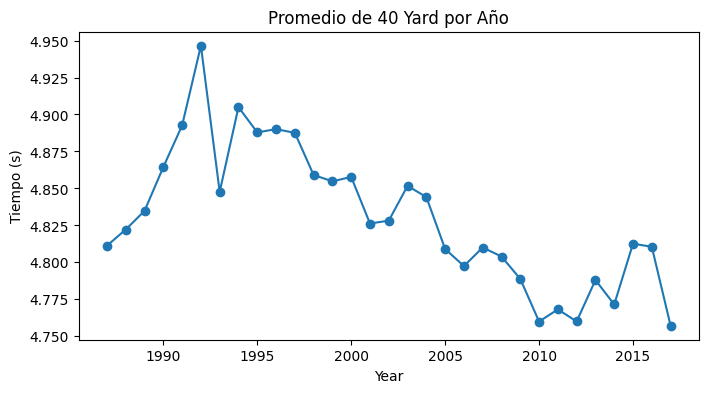

In [23]:
#Tendencia de año en 40m yardas
df.groupby("Year")["40 Yard"].mean().plot(marker='o', title="Promedio de 40 Yard por Año", figsize=(8,4))
plt.ylabel("Tiempo (s)")
plt.show()